# Ablation Study: GS-GLS Scalability

This notebook analyzes the scalability of GS-GLS compared to baselines across varying Hierarchy Sizes.

**Configuration:**
*   **Time Series Length**: Fixed at T = 2000 for all scenarios.
*   **Scenarios**: 10 different hierarchy structures ranging from small (~10 nodes) to large (~1000 nodes).

In [2]:
import numpy as np
import pandas as pd
import time
import random
import matplotlib.pyplot as plt

from hierarchy import Hierarchy
from data_generator import HierarchicalDataGenerator
from gs_gls import GSGLS
import baselines
from fair_baselines import BaselineReconciler

%load_ext autoreload
%autoreload 2

## 1. Experiment Setup

In [3]:
def generate_hierarchy(depth, branching_factor):
    # Set seed inside to ensure deterministic structure for same parameters
    np.random.seed(42)
    random.seed(42)
    structure = {}
    current_layer = ['Total']
    node_ctr = 1
    for d in range(depth):
        next_layer = []
        for parent in current_layer:
            # Use branching_factor as max, but ensure at least 2 children for structure
            # To get larger trees, we bias towards the max
            n_children = random.randint(max(2, branching_factor-2), branching_factor)
            children = []
            for _ in range(n_children):
                child_name = f'Node_{d+1}_{node_ctr}'
                children.append(child_name)
                node_ctr += 1
            structure[parent] = children
            next_layer.extend(children)
        current_layer = next_layer
    return Hierarchy(structure)

def run_experiment(config):
    name = config['name']
    depth = config['depth']
    branch = config['branch']
    n_total = 2000 # Fixed T
    n_train = int(n_total * 0.8)
    n_t_block = 10
    
    print(f"\nrunning Scenario: {name} (Depth={depth}, Branch={branch}, T={n_total})")
    
    # 1. Generate Hierarchy
    h = generate_hierarchy(depth, branch)
    print(f"  Hierarchy Nodes: {h.n_nodes}")
    
    # 2. Generate Data
    gen = HierarchicalDataGenerator(h, n_timesteps=n_total)
    Y_true = gen.generate_ground_truth()
    E = gen.generate_spatiotemporal_noise(spatial_rho=1.5, temporal_ar_coefs=[0.5], noise_scale=1.0)
    Y_hat = Y_true + E
    
    residuals_train = E[:, :n_train]
    Y_hat_test = Y_hat[:, n_train:]
    Y_true_test = Y_true[:, n_train:]
    
    # 3. Setup Baselines
    S_sp = h.get_summing_matrix()
    S_total = baselines.build_spatiotemporal_s(S_sp, n_t_block)
    
    train_blocks = []
    for i in range(0, residuals_train.shape[1] - n_t_block + 1, n_t_block):
        block = residuals_train[:, i:i+n_t_block]
        train_blocks.append(block.flatten(order='F'))
    residuals_samples = np.array(train_blocks)
    
    results = []
    
    # 4. Run Methods
    methods = [
        ('MinT_Shrink', 'baseline', None),
        ('GS-GLS (Spec)', 'gs', 'spectral')
    ]
    
    for label, mode, submode in methods:
        try:
            # Train
            t0 = time.time()
            if mode == 'baseline':
                model = BaselineReconciler(label, S_total)
                model.fit(residuals_samples)
            else:
                model = GSGLS(h, temporal_method=submode)
                model.fit(residuals_train)
            train_time = time.time() - t0
            
            # Infer
            t0 = time.time()
            mse_list = []
            # Limit inference batches if N is large to save time in demo
            limit_inference = 50 if h.n_nodes > 500 else 1000
            count = 0
            for i in range(0, Y_hat_test.shape[1] - n_t_block + 1, n_t_block):
                if count >= limit_inference: break
                count += 1
                
                y_hat_blk = Y_hat_test[:, i:i+n_t_block]
                y_true_blk = Y_true_test[:, i:i+n_t_block]
                
                if mode == 'baseline':
                    y_hat_flat = y_hat_blk.flatten(order='F')
                    y_tilde_flat = model.reconcile(y_hat_flat)
                    y_tilde_blk = y_tilde_flat.reshape((h.n_nodes, n_t_block), order='F')
                else:
                    y_tilde_blk = model.reconcile(y_hat_blk)
                    
                mse_list.append(np.mean((y_tilde_blk - y_true_blk)**2))
            infer_time = time.time() - t0
            # Scale inference time to full set if limited
            if count < (Y_hat_test.shape[1] // n_t_block):
                 ratio = (Y_hat_test.shape[1] // n_t_block) / count
                 infer_time *= ratio
            
            results.append({
                'Scenario': name,
                'Nodes': h.n_nodes,
                'Method': label,
                'Train Time': train_time,
                'Infer Time': infer_time,
                'Total Time': train_time + infer_time,
                'MSE': np.mean(mse_list)
            })
        except Exception as e:
            print(f"Error in {label}: {e}")
            
    return results

## 2. Run 10 Scenarios

In [4]:
# Revised parameters for wider range of nodes
scenarios = [
    {'name': 'XS', 'depth': 2, 'branch': 3},   
    {'name': 'S1', 'depth': 3, 'branch': 3},   
    {'name': 'S2', 'depth': 3, 'branch': 4},   
    {'name': 'M1', 'depth': 4, 'branch': 3},   
    {'name': 'M2', 'depth': 3, 'branch': 6},   
    {'name': 'L1', 'depth': 4, 'branch': 4},   
    {'name': 'L2', 'depth': 4, 'branch': 5},
    {'name': 'XL1', 'depth': 5, 'branch': 4},
    {'name': 'XL2', 'depth': 5, 'branch': 5}, 
    {'name': 'XXL', 'depth': 6, 'branch': 4},
]

all_results = []
for sc in scenarios:
    res = run_experiment(sc)
    all_results.extend(res)

df_ablation = pd.DataFrame(all_results)
display(df_ablation)


running Scenario: XS (Depth=2, Branch=3, T=2000)
  Hierarchy Nodes: 8

running Scenario: S1 (Depth=3, Branch=3, T=2000)
  Hierarchy Nodes: 18

running Scenario: S2 (Depth=3, Branch=4, T=2000)
  Hierarchy Nodes: 49

running Scenario: M1 (Depth=4, Branch=3, T=2000)
  Hierarchy Nodes: 40

running Scenario: M2 (Depth=3, Branch=6, T=2000)
  Hierarchy Nodes: 171

running Scenario: L1 (Depth=4, Branch=4, T=2000)
  Hierarchy Nodes: 142

running Scenario: L2 (Depth=4, Branch=5, T=2000)
  Hierarchy Nodes: 369

running Scenario: XL1 (Depth=5, Branch=4, T=2000)
  Hierarchy Nodes: 425

running Scenario: XL2 (Depth=5, Branch=5, T=2000)
  Hierarchy Nodes: 1463

running Scenario: XXL (Depth=6, Branch=4, T=2000)
  Hierarchy Nodes: 1265


,Scenario,Nodes,Method,Train Time,Infer Time,Total Time,MSE
0,XS,8,MinT_Shrink,0.003031,0.000000,0.003031,0.960124
1,XS,8,GS-GLS (Spec),0.431562,0.015624,0.447187,0.802681
2,S1,18,MinT_Shrink,0.000000,0.006022,0.006022,0.944674
3,S1,18,GS-GLS (Spec),0.452529,0.003003,0.455531,0.768343
4,S2,49,MinT_Shrink,0.014243,0.002568,0.016811,0.967045
5,S2,49,GS-GLS (Spec),0.450056,0.000511,0.450567,0.746544
6,M1,40,MinT_Shrink,0.017679,0.000000,0.017679,0.922754
7,M1,40,GS-GLS (Spec),0.449825,0.000000,0.449825,0.728623
8,M2,171,MinT_Shrink,0.271607,0.011162,0.282770,0.993548
9,M2,171,GS-GLS (Spec),0.550197,0.000000,0.550197,0.778343


## 3. Scalability Plots

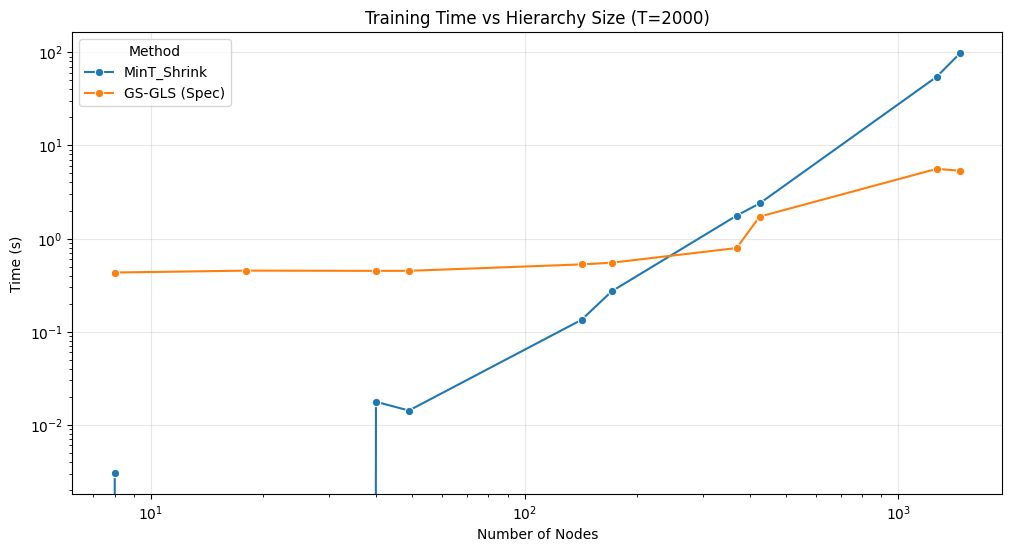

In [5]:
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_ablation, x='Nodes', y='Train Time', hue='Method', marker='o')
plt.title("Training Time vs Hierarchy Size (T=2000)")
plt.xlabel("Number of Nodes")
plt.ylabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.show()